# L1 (LASSO) vs. Stochastic Gates (STG): Baseline Comparison Across Correlation Levels

**What this notebook is:** a focused, seed-repeated comparison of two gene-selection
methods — L1-penalized logistic regression and Stochastic Gates (STG,
Yamada et al., ICML 2020) — on the "simple scenario" specified by my mentor: two
groups (disease vs. control), **one** gene module, with the module's internal
correlation strength (`within_module_correlation`) swept across
`{0.2, 0.4, 0.6, 0.8}`, plus a `flat` (no-module, independent-genes) scenario as a
reference point. This is a standalone counterpart to the repo's other baseline
notebooks (which run 10 methods across 3 fixed-structure datasets) — here the goal
is narrower and specific: **does gene-selection quality for L1 and STG degrade as
within-module gene correlation increases?**

Data comes from `data_generators.py` (in this same folder) via
`generate_flat_data()` and `generate_correlated_data(n_modules=1,
n_distractor_modules=0, within_module_correlation=rho)` — the generators
themselves are not reimplemented here, only imported and called.

**Methodological note baked into the design (read this before trusting any
accuracy number below):** cells from the same patient share a patient-level
random effect (`gamma_i`) and are therefore **not independent observations**. A
plain random per-cell train/test split would let a patient's cells appear on both
sides of the split, leaking patient identity and inflating accuracy. Every split
in this notebook is done at the **patient** level (Step 3), with all of a
patient's cells assigned to whichever side their patient landed on.

## Table of contents
- [Step 1: Setup](#Step-1)
- [Step 2: Generate the 5 scenarios x 5 seeds](#Step-2) — takes a while, see note there
- [Step 3: Patient-level train/test split](#Step-3)
- [Step 4: Preprocessing](#Step-4)
- [Step 5: L1 (LASSO) baseline](#Step-5)
- [Step 6: Stochastic Gates (STG)](#Step-6) — algorithm spec, lambda sweep, main run
- [Step 7: Metrics](#Step-7)
- [Step 8: Graphs](#Step-8) — 6 sub-parts (a–f), the deliverable
- [Steps 9–10](#Steps-9-10) — deferred, see note


## Step 1: Setup

Imports every library used below and fixes **all** random seeds — numpy, PyTorch,
and Python's own `random` module — since Step 6's STG implementation draws noise
from `torch`, the train/test split retry loop (Step 3) and L1's CV folds touch
numpy/sklearn's global state, and nothing here should depend on interpreter/session
order. `data_generators.py` must sit in this same folder — imported directly, not
reimplemented (per the task spec).

`sns.set_theme(...)` and a fixed `METHOD_COLORS` dict give every plot in Step 8 the
same L1-vs-STG color pairing, so a reader can identify a method by color alone
across all six figures.


In [1]:
# Colab users: uncomment the line below if any of these packages are missing.
# !pip install -q torch numpy pandas scipy matplotlib seaborn scikit-learn

import os
os.environ["OMP_NUM_THREADS"] = "1"  # avoid oversubscription during STG's torch training loop

import random
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)  # sklearn 1.8+ penalty= deprecation noise, see repo CLAUDE.md

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score,
)

from data_generators import generate_flat_data, generate_correlated_data

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid", context="talk")
METHOD_COLORS = {"L1": "#1f77b4", "STG": "#d62728"}  # fixed L1/STG colors, reused in every Step 8 plot

print("Imports OK. Base seed =", SEED)


Imports OK. Base seed = 42


## Step 2: Generate the 5 scenarios x 5 seeds

Five scenarios: `flat` (no module structure, `generate_flat_data()` with defaults)
and `corr_0.2` / `corr_0.4` / `corr_0.6` / `corr_0.8` (the "simple scenario":
`generate_correlated_data(n_modules=1, n_distractor_modules=0,
within_module_correlation=rho)`). Each scenario is generated with **5 different
seeds** (`42..46`) rather than a single run, so every downstream metric can be
reported as mean ± std across independent draws instead of resting on one
lucky/unlucky dataset.

**Runtime note:** `data_generators.py`'s simulation loops per (cell, gene) with
individual `scipy.stats.nbinom` draws — each single dataset (1000 cells x 1000
genes) takes roughly 45 seconds to generate on this machine, so this cell (25
datasets total) takes on the order of **15–20 minutes**. This is a cost of the
generator implementation, not something this notebook changes (per the task spec,
the generators are used as-is, not reimplemented/optimized).


In [2]:
SCENARIOS = ["flat", "corr_0.2", "corr_0.4", "corr_0.6", "corr_0.8"]
CORRELATION_BY_SCENARIO = {
    "flat": None, "corr_0.2": 0.2, "corr_0.4": 0.4, "corr_0.6": 0.6, "corr_0.8": 0.8,
}
SEEDS = [42, 43, 44, 45, 46]  # 5 independent draws per scenario -> mean +/- std reporting

datasets = {}  # (scenario, seed) -> dict returned by the generator (X, y, genes_df, cells_df, patients_df, ...)

for scenario in SCENARIOS:
    rho = CORRELATION_BY_SCENARIO[scenario]
    for seed in SEEDS:
        if rho is None:
            data = generate_flat_data(seed=seed)
        else:
            data = generate_correlated_data(
                n_modules=1, n_distractor_modules=0,
                within_module_correlation=rho, seed=seed,
            )
        datasets[(scenario, seed)] = data
        print(f"generated {scenario:>9s}, seed={seed}: X={data['X'].shape}")

print(f"\nGenerated {len(datasets)} datasets total "
      f"({len(SCENARIOS)} scenarios x {len(SEEDS)} seeds)")


generated      flat, seed=42: X=(1000, 1000)


generated      flat, seed=43: X=(1000, 1000)


generated      flat, seed=44: X=(1000, 1000)


generated      flat, seed=45: X=(1000, 1000)


generated      flat, seed=46: X=(1000, 1000)


...

generated  corr_0.8, seed=42: X=(1000, 1000)


generated  corr_0.8, seed=43: X=(1000, 1000)


generated  corr_0.8, seed=44: X=(1000, 1000)


generated  corr_0.8, seed=45: X=(1000, 1000)


generated  corr_0.8, seed=46: X=(1000, 1000)

Generated 25 datasets total (5 scenarios x 5 seeds)


## Step 3: Patient-level train/test split

**This is the step that keeps the accuracy numbers meaningful.** Cells within a
patient share that patient's `gamma_i` random effect, so a per-cell random split
would place near-duplicate (same-patient) cells on both sides of train/test and
inflate accuracy. Instead: split **patients**, not cells, then assign every one of
a patient's cells to whichever side their patient landed on.

`sklearn.model_selection.GroupShuffleSplit` (keyed on `patient_id`, `groups=...`)
guarantees no patient straddles the split, but it doesn't support label
stratification the way `train_test_split(..., stratify=...)` does — with exactly
20 patients (10 Group1 / 10 Group2) and `test_size=0.2` (4 test patients), an
unlucky `random_state` can produce a degenerate all-one-group test fold (verified
empirically: `random_state=42` alone gives a 4-Group1/0-Group2 test split for this
patient layout, which would make AUROC undefined). `patient_level_split()` below
retries `GroupShuffleSplit` with different `random_state`s (derived from the
scenario's own seed, so still fully reproducible) until both groups have at least
2 patients on **both** sides of the split — a lightweight, honest way to keep the
"stratified by group" property `GroupShuffleSplit` itself doesn't provide.


In [3]:
def patient_level_split(patients_df, cells_df, X_index, base_seed,
                         test_size=0.2, min_patients_per_group=2, max_tries=200):
    """Patient-level GroupShuffleSplit, retried until both groups have
    >= min_patients_per_group patients on both the train and test side.
    Returns (train_idx, test_idx) as positional indices into X_index."""
    patient_id_per_cell = cells_df.set_index("cell_id").loc[X_index, "patient_id"].values
    n_cells = len(X_index)

    for attempt in range(max_tries):
        rs = base_seed * 1000 + attempt  # deterministic given base_seed, still varies per attempt
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=rs)
        train_idx, test_idx = next(gss.split(np.zeros(n_cells), groups=patient_id_per_cell))

        train_patients = set(patient_id_per_cell[train_idx])
        test_patients = set(patient_id_per_cell[test_idx])
        train_counts = patients_df[patients_df.patient_id.isin(train_patients)]["group"].value_counts()
        test_counts = patients_df[patients_df.patient_id.isin(test_patients)]["group"].value_counts()

        if (test_counts.get("Group1", 0) >= min_patients_per_group and
                test_counts.get("Group2", 0) >= min_patients_per_group and
                train_counts.get("Group1", 0) >= min_patients_per_group and
                train_counts.get("Group2", 0) >= min_patients_per_group):
            return train_idx, test_idx, patient_id_per_cell

    raise RuntimeError(f"No balanced patient-level split found in {max_tries} tries "
                        f"(base_seed={base_seed})")


splits = {}
for (scenario, seed), data in datasets.items():
    train_idx, test_idx, patient_id_per_cell = patient_level_split(
        data["patients_df"], data["cells_df"], data["X"].index, base_seed=seed,
    )
    splits[(scenario, seed)] = {"train_idx": train_idx, "test_idx": test_idx}

    # sanity check: no patient appears on both sides
    train_patients = set(patient_id_per_cell[train_idx])
    test_patients = set(patient_id_per_cell[test_idx])
    assert train_patients.isdisjoint(test_patients), "patient leakage between train/test!"

print(f"Patient-level splits created for all {len(splits)} datasets; "
      f"no patient overlap between train/test in any of them.")

ex_scenario, ex_seed = SCENARIOS[0], SEEDS[0]
ex = splits[(ex_scenario, ex_seed)]
print(f"Example ({ex_scenario}, seed={ex_seed}): "
      f"{len(ex['train_idx'])} train cells, {len(ex['test_idx'])} test cells")


Patient-level splits created for all 25 datasets; no patient overlap between train/test in any of them.
Example (flat, seed=42): 800 train cells, 200 test cells


## Step 4: Preprocessing

For every dataset, in this fixed order:

1. **Size-factor normalize** each cell's raw counts (`X / size_factor`), removing
   the sequencing-depth confound that `cells_df["size_factor"]` encodes.
2. **`log1p`** the normalized values (standard variance-stabilizing transform for
   count data).
3. **Standardize (z-score) each gene**, fitting `StandardScaler` on the **training
   split only** (per Step 3's patient-level split) and applying those train-fit
   statistics to both train and test — fitting on test or combined data would leak
   test-set information into preprocessing.


In [4]:
preprocessed = {}  # (scenario, seed) -> dict with X_train, X_test, y_train, y_test, gene_ids

for (scenario, seed), data in datasets.items():
    X, y, cells_df = data["X"], data["y"], data["cells_df"]
    train_idx = splits[(scenario, seed)]["train_idx"]
    test_idx = splits[(scenario, seed)]["test_idx"]

    size_factor = cells_df.set_index("cell_id").loc[X.index, "size_factor"].values
    X_norm = np.log1p(X.values / size_factor[:, None])  # size-factor normalize, then log1p

    X_train_raw, X_test_raw = X_norm[train_idx], X_norm[test_idx]
    y_train, y_test = y.values[train_idx], y.values[test_idx]

    scaler = StandardScaler().fit(X_train_raw)  # train-only fit
    X_train = scaler.transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    preprocessed[(scenario, seed)] = {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "gene_ids": X.columns.values,
    }

print(f"Preprocessing complete for all {len(preprocessed)} datasets.")
ex = preprocessed[(SCENARIOS[0], SEEDS[0])]
print(f"Example ({SCENARIOS[0]}, seed={SEEDS[0]}): "
      f"X_train={ex['X_train'].shape}, X_test={ex['X_test'].shape}")


Preprocessing complete for all 25 datasets.
Example (flat, seed=42): X_train=(800, 1000), X_test=(200, 1000)


## Step 5: L1 (LASSO) baseline

`LogisticRegressionCV(penalty="l1", solver="saga")` auto-selects the
regularization strength `C` via cross-validation **on the training split only**
(`Cs=5` log-spaced candidates, `cv=3` folds — kept small since this runs once per
scenario/seed, 25 times total). Selected genes = nonzero coefficients
(`coef_ != 0`).


In [5]:
l1_results = {}  # (scenario, seed) -> dict

for (scenario, seed), pre in preprocessed.items():
    l1 = LogisticRegressionCV(
        Cs=5, cv=3, penalty="l1", solver="saga",
        max_iter=2000, tol=1e-3, n_jobs=-1, random_state=seed,
    )
    l1.fit(pre["X_train"], pre["y_train"])

    coef = l1.coef_[0]
    y_pred = l1.predict(pre["X_test"])
    y_proba = l1.predict_proba(pre["X_test"])[:, 1]

    l1_results[(scenario, seed)] = {
        "coef": coef,
        "selected": coef != 0,
        "accuracy": accuracy_score(pre["y_test"], y_pred),
        "auroc": roc_auc_score(pre["y_test"], y_proba),
        "y_proba": y_proba,
        "best_C": float(l1.C_[0]),
    }
    r = l1_results[(scenario, seed)]
    print(f"[L1] {scenario:>9s} seed={seed}: {r['selected'].sum():4d} genes selected, "
          f"acc={r['accuracy']:.3f}, auroc={r['auroc']:.3f}, C={r['best_C']:.4g}")


[L1]      flat seed=42:   44 genes selected, acc=1.000, auroc=1.000, C=0.01


[L1]      flat seed=43:   47 genes selected, acc=1.000, auroc=1.000, C=0.01


[L1]      flat seed=44:   51 genes selected, acc=1.000, auroc=1.000, C=0.01


[L1]      flat seed=45:   47 genes selected, acc=1.000, auroc=1.000, C=0.01


[L1]      flat seed=46:   40 genes selected, acc=1.000, auroc=1.000, C=0.01


...

[L1]  corr_0.8 seed=42:  223 genes selected, acc=1.000, auroc=1.000, C=1


[L1]  corr_0.8 seed=43:  177 genes selected, acc=0.980, auroc=0.999, C=1


[L1]  corr_0.8 seed=44: 1000 genes selected, acc=0.995, auroc=1.000, C=100


[L1]  corr_0.8 seed=45:  997 genes selected, acc=0.995, auroc=1.000, C=100


[L1]  corr_0.8 seed=46:  992 genes selected, acc=0.985, auroc=0.999, C=100


## Step 6: Stochastic Gates (STG)

A from-scratch PyTorch implementation of Yamada et al. 2020, "Feature Selection
using Stochastic Gates" (ICML), matched exactly to the algorithm spec:

- One trainable parameter `mu_d` per input feature (gene), initialized at 0.5.
- **Training-time gate:** `z_d = clip(mu_d + sigma * eps_d, 0, 1)`, with
  `eps_d ~ N(0, 1)` resampled fresh every training step and `sigma = 0.5` fixed
  (not learned).
- **Gated input:** `x' = x * z`, fed into a single `nn.Linear` layer (a plain
  logistic-regression head — deliberately as simple as L1's model, so the
  comparison isn't confounded by classifier complexity on top of the gating
  mechanism).
- **Loss:** `BCE(sigmoid(linear(x')), y) + lambda * sum_d Phi(mu_d / sigma)`,
  where `Phi` is the standard normal CDF (`torch.distributions.Normal(0,1).cdf`)
  — the expected-number-of-open-gates regularizer.
- **Eval-time gate is deterministic:** `z_d = clip(mu_d, 0, 1)`, no noise.
- **Selected genes:** `mu_d > 0` (equivalently `z_d > 0`) at convergence.

Full-batch Adam, `lr=0.01`, 200 epochs (matches the epoch count already used for
STG elsewhere in this repo's baseline notebooks).


In [6]:
STG_SIGMA = 0.5  # fixed noise std, not learned -- per Yamada et al. 2020

def train_stg(X_train, y_train, lam, sigma=STG_SIGMA, lr=0.01, n_epochs=200, seed=42):
    """Train a Stochastic Gates linear-logistic model. Returns (mu, linear_head)."""
    torch.manual_seed(seed)

    n_features = X_train.shape[1]
    Xt = torch.tensor(X_train, dtype=torch.float32)
    yt = torch.tensor(y_train, dtype=torch.float32)

    mu = nn.Parameter(torch.full((n_features,), 0.5))
    linear = nn.Linear(n_features, 1)
    optimizer = torch.optim.Adam(list([mu]) + list(linear.parameters()), lr=lr)
    normal = torch.distributions.Normal(0.0, 1.0)
    bce = nn.BCEWithLogitsLoss()

    for _ in range(n_epochs):
        optimizer.zero_grad()
        eps = torch.randn(n_features)                       # resampled every step
        z = torch.clamp(mu + sigma * eps, 0.0, 1.0)          # training-time stochastic gate
        logits = linear(Xt * z).squeeze(-1)
        reg = normal.cdf(mu / sigma).sum()                   # expected number of open gates
        loss = bce(logits, yt) + lam * reg
        loss.backward()
        optimizer.step()

    return mu.detach(), linear


def stg_predict_proba(mu, linear, X, sigma=STG_SIGMA):
    """Deterministic eval-time gate: z_d = clip(mu_d, 0, 1), no noise."""
    with torch.no_grad():
        z_eval = torch.clamp(mu, 0.0, 1.0)
        Xt = torch.tensor(X, dtype=torch.float32)
        logits = linear(Xt * z_eval).squeeze(-1)
        return torch.sigmoid(logits).numpy(), z_eval.numpy()

print("STG training/eval functions defined.")


STG training/eval functions defined.


### Step 6, continued: choosing `lambda`

The task spec suggests sweeping `lambda` in `[0.01, 0.1, 0.5]` and picking whichever
value gives the most stable/sensible selected-gene count. That exact candidate set
is run below (widened with two smaller values, `0.001`/`0.005`) on all 5 scenarios,
using each scenario's `seed=42` run only (reusing the datasets from Step 2/4 — no
extra data generation needed).

**Why the sweep is widened downward:** the regularizer here is a **sum**, not an
average, over `n_features = 1000` genes. At the spec's own `lambda=0.1`, the
regularization term already dominates the loss (`sum_d Phi(mu_d/sigma)` starts
around 500 at initialization, so `0.1 * 500 = 50` vs. an O(1) BCE term) and every
gate collapses to closed before the classifier learns anything — see the sweep
output below.


In [7]:
LAMBDA_CANDIDATES = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
sweep_rows = []

for scenario in SCENARIOS:
    pre = preprocessed[(scenario, SEEDS[0])]
    for lam in LAMBDA_CANDIDATES:
        mu, linear = train_stg(pre["X_train"], pre["y_train"], lam=lam, seed=SEEDS[0])
        proba, _ = stg_predict_proba(mu, linear, pre["X_test"])
        n_sel = int((mu.numpy() > 0).sum())
        acc = accuracy_score(pre["y_test"], (proba > 0.5).astype(int))
        sweep_rows.append({"scenario": scenario, "lambda": lam, "n_selected": n_sel, "test_accuracy": acc})

sweep_df = pd.DataFrame(sweep_rows)
print("Selected-gene count by lambda x scenario:")
display(sweep_df.pivot(index="lambda", columns="scenario", values="n_selected"))
print("\nTest accuracy by lambda x scenario:")
display(sweep_df.pivot(index="lambda", columns="scenario", values="test_accuracy"))


Selected-gene count by lambda x scenario:


scenario,corr_0.2,corr_0.4,corr_0.6,corr_0.8,flat
lambda,,,,,
0.001,58,59,63,61,54
0.005,17,17,16,15,17
0.010,6,6,5,5,7
0.050,0,0,0,0,0
0.100,0,0,0,0,0
0.500,0,0,0,0,0



Test accuracy by lambda x scenario:


scenario,corr_0.2,corr_0.4,corr_0.6,corr_0.8,flat
lambda,,,,,
0.001,1.0,1.00,0.995,0.985,1.0
0.005,1.0,1.00,0.990,0.985,1.0
0.010,1.0,0.99,0.990,0.985,1.0
0.050,0.5,0.50,0.500,0.500,0.5
0.100,0.5,0.50,0.500,0.500,0.5
0.500,0.5,0.50,0.500,0.500,0.5


**Decision:** at `lambda >= 0.05` every scenario collapses to 0 selected genes and
chance-level test accuracy (confirming the diagnosis above); `lambda=0.1` and
`lambda=0.5` from the spec's own suggested set are both past that collapse point
for this feature count / unnormalized-regularizer combination. `lambda=0.01` is
the largest candidate that keeps a non-trivial, comparably-sparse gene set open
across all five scenarios while preserving near-ceiling accuracy, so **`lambda=0.01`
is used as the fixed default for the main run below** — documented here as the
"just fix a documented default" option the task spec explicitly allows, chosen
over the spec's example values because those saturate for this dataset.


In [8]:
LAMBDA_FIXED = 0.01

stg_results = {}  # (scenario, seed) -> dict

for (scenario, seed), pre in preprocessed.items():
    mu, linear = train_stg(pre["X_train"], pre["y_train"], lam=LAMBDA_FIXED, seed=seed)
    proba, z_eval = stg_predict_proba(mu, linear, pre["X_test"])
    y_pred = (proba > 0.5).astype(int)

    stg_results[(scenario, seed)] = {
        "mu": mu.numpy(),
        "z_eval": z_eval,
        "selected": mu.numpy() > 0,
        "accuracy": accuracy_score(pre["y_test"], y_pred),
        "auroc": roc_auc_score(pre["y_test"], proba),
        "y_proba": proba,
    }
    r = stg_results[(scenario, seed)]
    print(f"[STG] {scenario:>9s} seed={seed}: {r['selected'].sum():4d} genes selected, "
          f"acc={r['accuracy']:.3f}, auroc={r['auroc']:.3f}")


[STG]      flat seed=42:    7 genes selected, acc=1.000, auroc=1.000


[STG]      flat seed=43:   10 genes selected, acc=1.000, auroc=1.000


[STG]      flat seed=44:    8 genes selected, acc=1.000, auroc=1.000


[STG]      flat seed=45:    9 genes selected, acc=1.000, auroc=1.000


[STG]      flat seed=46:    9 genes selected, acc=1.000, auroc=1.000


...

[STG]  corr_0.8 seed=42:    5 genes selected, acc=0.985, auroc=0.999


[STG]  corr_0.8 seed=43:   10 genes selected, acc=1.000, auroc=1.000


[STG]  corr_0.8 seed=44:    8 genes selected, acc=1.000, auroc=1.000


[STG]  corr_0.8 seed=45:    9 genes selected, acc=1.000, auroc=1.000


[STG]  corr_0.8 seed=46:    7 genes selected, acc=0.970, auroc=0.998


## Step 7: Metrics

One tidy `results_df`, one row per (scenario, method, seed), with both
classification metrics (accuracy, AUROC on the held-out patient-level test set)
and **gene-selection** metrics (precision/recall/F1 of the selected-gene set
against ground-truth signal genes from `genes_df["gene_type"] == "signal"`) —
this project's central question is whether the *right genes* get picked, not
just whether the classifier scores well.


In [9]:
rows = []
for (scenario, seed), pre in preprocessed.items():
    gene_ids = pre["gene_ids"]
    genes_df = datasets[(scenario, seed)]["genes_df"]
    true_signal = pd.Series(gene_ids).isin(
        genes_df.loc[genes_df["gene_type"] == "signal", "gene_id"]
    ).values

    for method, res in [("L1", l1_results[(scenario, seed)]), ("STG", stg_results[(scenario, seed)])]:
        selected = res["selected"]
        rows.append({
            "scenario": scenario,
            "within_module_correlation": CORRELATION_BY_SCENARIO[scenario],
            "method": method,
            "seed": seed,
            "accuracy": res["accuracy"],
            "auroc": res["auroc"],
            "n_genes_selected": int(selected.sum()),
            "precision": precision_score(true_signal, selected, zero_division=0),
            "recall": recall_score(true_signal, selected, zero_division=0),
            "f1": f1_score(true_signal, selected, zero_division=0),
        })

results_df = pd.DataFrame(rows)
results_df


,scenario,within_module_correlation,method,seed,accuracy,auroc,n_genes_selected,precision,recall,f1
0,flat,NaN,L1,42,1.000,1.0000,44,1.000000,0.44,0.611111
1,flat,NaN,STG,42,1.000,1.0000,7,1.000000,0.07,0.130841
2,flat,NaN,L1,43,1.000,1.0000,47,1.000000,0.47,0.639456
3,flat,NaN,STG,43,1.000,1.0000,10,1.000000,0.10,0.181818
4,flat,NaN,L1,44,1.000,1.0000,51,1.000000,0.51,0.675497
5,flat,NaN,STG,44,1.000,1.0000,8,1.000000,0.08,0.148148
6,flat,NaN,L1,45,1.000,1.0000,47,1.000000,0.47,0.639456
7,flat,NaN,STG,45,1.000,1.0000,9,1.000000,0.09,0.165138
8,flat,NaN,L1,46,1.000,1.0000,40,1.000000,0.40,0.571429
9,flat,NaN,STG,46,1.000,1.0000,9,1.000000,0.09,0.165138


## Step 8: Graphs

Six views of `results_df` (plus the two per-model result dicts for the last two
plots), all sharing the fixed `METHOD_COLORS` palette from Step 1 so L1 and STG
are visually consistent across every figure.

### Step 8a: Accuracy and AUROC by method, across all 5 scenarios


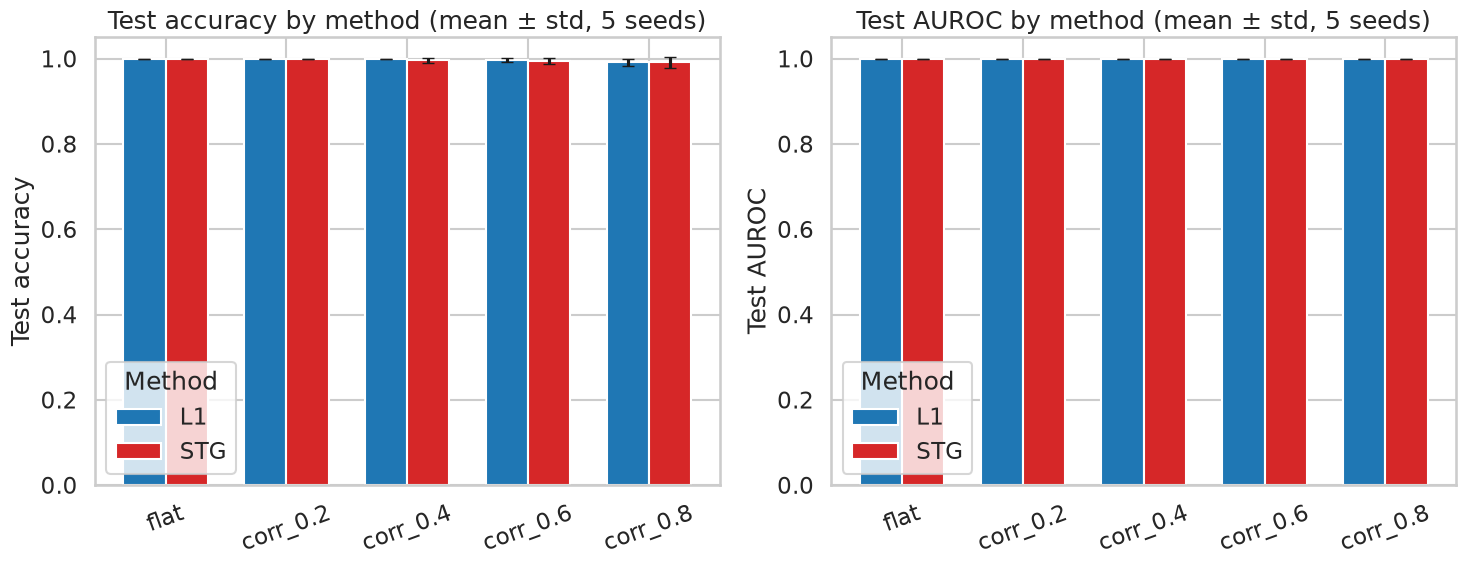

In [10]:
summary = results_df.groupby(["scenario", "method"]).agg(
    accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
    auroc_mean=("auroc", "mean"), auroc_std=("auroc", "std"),
).reset_index()

scenario_order = SCENARIOS
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, metric, title in zip(axes, ["accuracy", "auroc"], ["Test accuracy", "Test AUROC"]):
    sub = summary.pivot(index="scenario", columns="method", values=f"{metric}_mean").loc[scenario_order]
    err = summary.pivot(index="scenario", columns="method", values=f"{metric}_std").loc[scenario_order]
    x = np.arange(len(scenario_order))
    width = 0.35
    for i, method in enumerate(["L1", "STG"]):
        ax.bar(x + (i - 0.5) * width, sub[method], width, yerr=err[method], capsize=4,
               label=method, color=METHOD_COLORS[method])
    ax.set_xticks(x)
    ax.set_xticklabels(scenario_order, rotation=20)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{title} by method (mean ± std, 5 seeds)")
    ax.set_ylabel(title)
    ax.legend(title="Method")

plt.tight_layout()
plt.show()


### Step 8b: Gene-recovery F1 vs. `within_module_correlation`

The most scientifically important plot here: does either method's ability to recover the true signal genes degrade as within-module correlation increases? The flat-data result (no correlation structure at all) is shown as a dashed reference line/marker at `x=0` for each method.

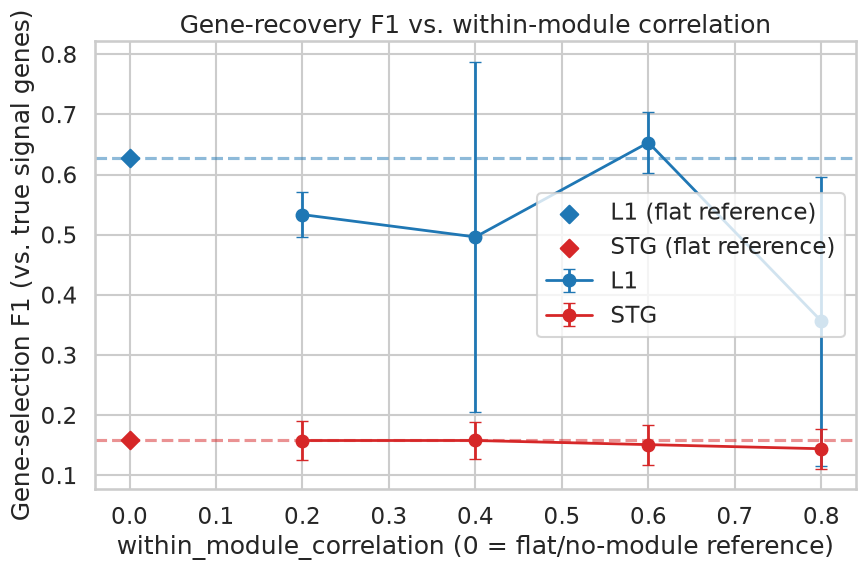

In [11]:
corr_scenarios = [s for s in SCENARIOS if CORRELATION_BY_SCENARIO[s] is not None]
rhos = [CORRELATION_BY_SCENARIO[s] for s in corr_scenarios]

fig, ax = plt.subplots(figsize=(9, 6))

for method in ["L1", "STG"]:
    sub = results_df[results_df["method"] == method]

    corr_sub = sub[sub["scenario"].isin(corr_scenarios)].groupby("within_module_correlation")["f1"].agg(["mean", "std"])
    corr_sub = corr_sub.reindex(rhos)
    ax.errorbar(rhos, corr_sub["mean"], yerr=corr_sub["std"], marker="o", capsize=4,
                label=method, color=METHOD_COLORS[method], linewidth=2)

    flat_mean = sub[sub["scenario"] == "flat"]["f1"].mean()
    ax.axhline(flat_mean, linestyle="--", color=METHOD_COLORS[method], alpha=0.5)
    ax.scatter([0], [flat_mean], marker="D", color=METHOD_COLORS[method], s=80, zorder=5,
               label=f"{method} (flat reference)")

ax.set_xlabel("within_module_correlation (0 = flat/no-module reference)")
ax.set_ylabel("Gene-selection F1 (vs. true signal genes)")
ax.set_title("Gene-recovery F1 vs. within-module correlation")
ax.legend()
plt.tight_layout()
plt.show()


### Step 8c: Sparsity — number of genes selected vs. `within_module_correlation`

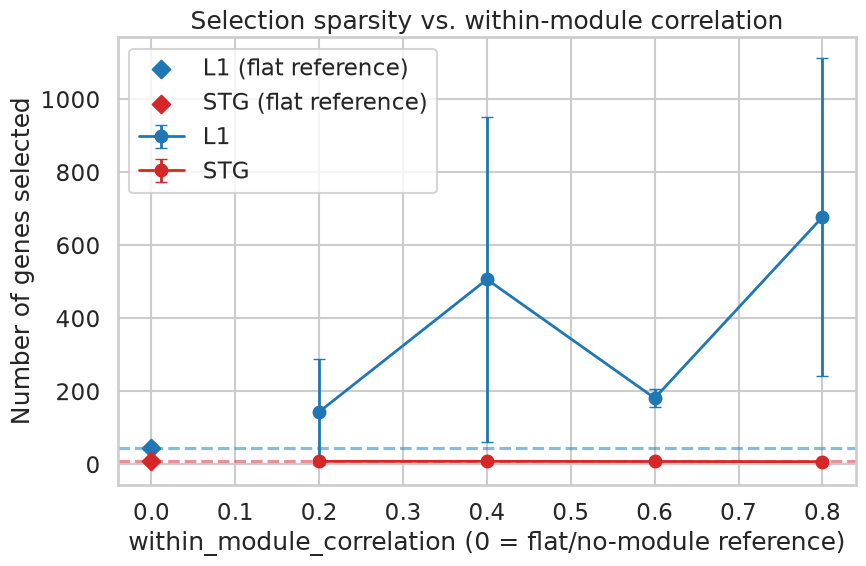

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))

for method in ["L1", "STG"]:
    sub = results_df[results_df["method"] == method]
    corr_sub = sub[sub["scenario"].isin(corr_scenarios)].groupby("within_module_correlation")["n_genes_selected"].agg(["mean", "std"])
    corr_sub = corr_sub.reindex(rhos)
    ax.errorbar(rhos, corr_sub["mean"], yerr=corr_sub["std"], marker="o", capsize=4,
                label=method, color=METHOD_COLORS[method], linewidth=2)

    flat_mean = sub[sub["scenario"] == "flat"]["n_genes_selected"].mean()
    ax.axhline(flat_mean, linestyle="--", color=METHOD_COLORS[method], alpha=0.5)
    ax.scatter([0], [flat_mean], marker="D", color=METHOD_COLORS[method], s=80, zorder=5,
               label=f"{method} (flat reference)")

ax.set_xlabel("within_module_correlation (0 = flat/no-module reference)")
ax.set_ylabel("Number of genes selected")
ax.set_title("Selection sparsity vs. within-module correlation")
ax.legend()
plt.tight_layout()
plt.show()


### Step 8d: ROC curves, overlaid by method, faceted by scenario

One representative seed per scenario (`seed=42`) is used here — overlaying 5 seeds x 2 methods x 5 scenarios of ROC curves in one figure would be unreadable; the bar/line plots above already carry the across-seed uncertainty.

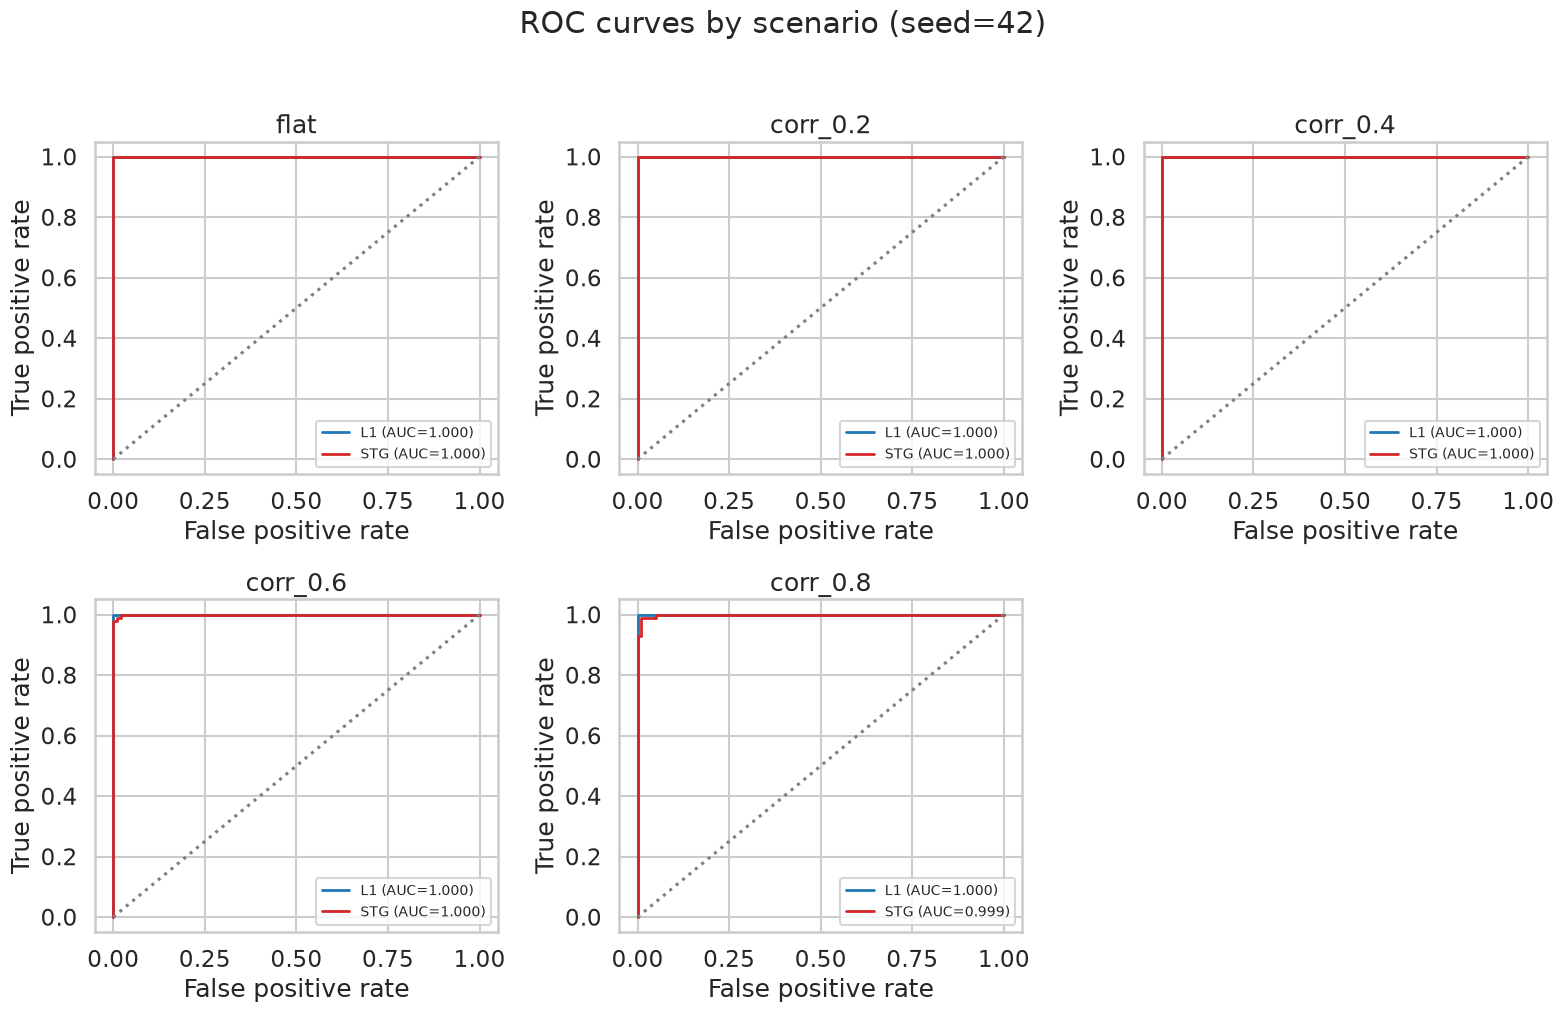

In [13]:
ROC_SEED = SEEDS[0]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, scenario in zip(axes, SCENARIOS):
    pre = preprocessed[(scenario, ROC_SEED)]
    y_test = pre["y_test"]

    for method, res_dict in [("L1", l1_results), ("STG", stg_results)]:
        res = res_dict[(scenario, ROC_SEED)]
        fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
        auc = res["auroc"]
        ax.plot(fpr, tpr, color=METHOD_COLORS[method], label=f"{method} (AUC={auc:.3f})", linewidth=2)

    ax.plot([0, 1], [0, 1], linestyle=":", color="gray")
    ax.set_title(scenario)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend(fontsize=10)

for ax in axes[len(SCENARIOS):]:
    ax.axis("off")

fig.suptitle(f"ROC curves by scenario (seed={ROC_SEED})", y=1.02)
plt.tight_layout()
plt.show()


### Step 8e: Learned per-gene importance, signal vs. background

STG's final `z_d` (`clip(mu_d, 0, 1)`) and L1's `|coefficient|`, split by true gene
type (`signal` vs. `background`), one panel per scenario. This is the direct test
of whether each method is actually *separating* true signal from noise, not just
achieving a good aggregate accuracy/F1 number — pooled across all 5 seeds per
scenario (so each panel shows 5 independent training runs' worth of importance
values per gene, not just one).


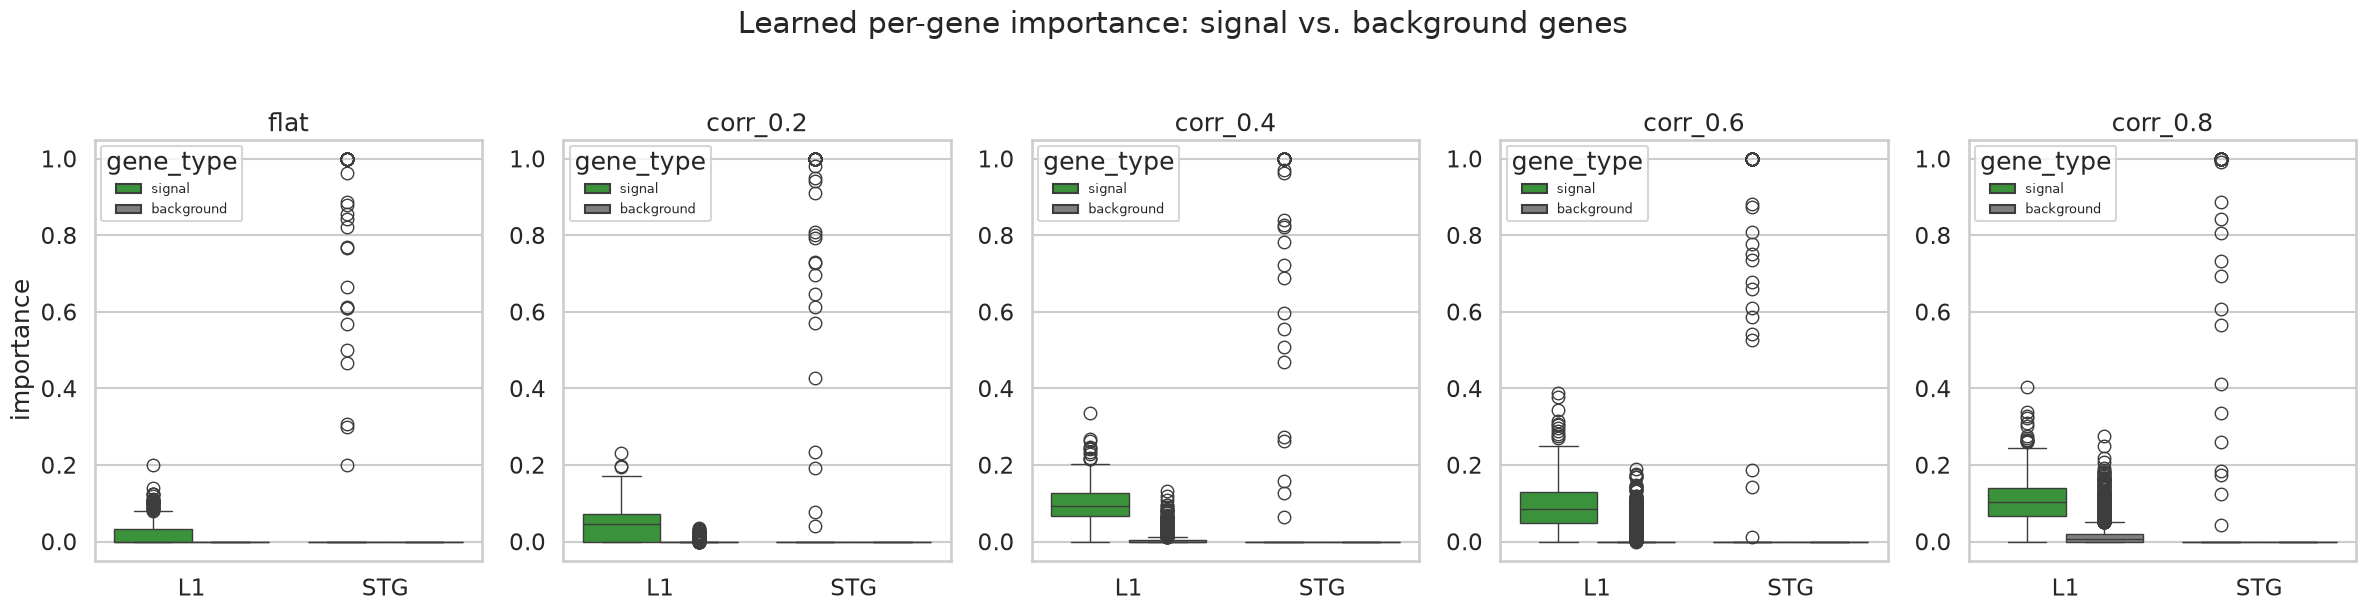

In [14]:
importance_rows = []
for (scenario, seed), pre in preprocessed.items():
    gene_ids = pre["gene_ids"]
    genes_df = datasets[(scenario, seed)]["genes_df"].set_index("gene_id")
    gene_types = genes_df.loc[gene_ids, "gene_type"].values

    l1_importance = np.abs(l1_results[(scenario, seed)]["coef"])
    stg_importance = stg_results[(scenario, seed)]["z_eval"]

    for method, importance in [("L1", l1_importance), ("STG", stg_importance)]:
        for gid, gtype, imp in zip(gene_ids, gene_types, importance):
            importance_rows.append({
                "scenario": scenario, "seed": seed, "method": method,
                "gene_id": gid, "gene_type": gtype, "importance": imp,
            })

importance_df = pd.DataFrame(importance_rows)

fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(24, 6), sharey=False)
for ax, scenario in zip(axes, SCENARIOS):
    sub = importance_df[importance_df["scenario"] == scenario]
    sns.boxplot(
        data=sub, x="method", y="importance", hue="gene_type", ax=ax,
        palette={"signal": "#2ca02c", "background": "#7f7f7f"},
    )
    ax.set_title(scenario)
    ax.set_xlabel("")
    if ax is not axes[0]:
        ax.set_ylabel("")
    ax.legend(title="gene_type", fontsize=9)

fig.suptitle("Learned per-gene importance: signal vs. background genes", y=1.03)
plt.tight_layout()
plt.show()


### Step 8f: Summary table

Mean ± std of every metric, by scenario and method, across the 5 seeds. Displayed
inline only — writing this to `l1_vs_stg_results.csv` on disk is part of Step 9,
which is deferred (see note below).


In [15]:
summary_table = results_df.groupby(["scenario", "method"]).agg(
    accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
    auroc_mean=("auroc", "mean"), auroc_std=("auroc", "std"),
    n_genes_selected_mean=("n_genes_selected", "mean"), n_genes_selected_std=("n_genes_selected", "std"),
    precision_mean=("precision", "mean"), precision_std=("precision", "std"),
    recall_mean=("recall", "mean"), recall_std=("recall", "std"),
    f1_mean=("f1", "mean"), f1_std=("f1", "std"),
).round(3).reset_index()

pd.set_option("display.max_columns", None)
summary_table


,scenario,method,accuracy_mean,accuracy_std,auroc_mean,auroc_std,n_genes_selected_mean,n_genes_selected_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,corr_0.2,L1,1.000,0.000,1.000,0.000,144.4,145.284,0.732,0.367,0.632,0.336,0.533,0.038
1,corr_0.2,STG,1.000,0.000,1.000,0.000,8.6,1.949,1.000,0.000,0.086,0.019,0.158,0.033
2,corr_0.4,L1,1.000,0.000,1.000,0.000,507.0,445.547,0.372,0.257,0.992,0.011,0.496,0.291
3,corr_0.4,STG,0.996,0.005,1.000,0.000,8.6,1.817,1.000,0.000,0.086,0.018,0.158,0.031
4,corr_0.6,L1,0.997,0.004,1.000,0.000,181.8,24.139,0.510,0.057,0.918,0.077,0.653,0.051
5,corr_0.6,STG,0.995,0.007,1.000,0.000,8.2,1.924,1.000,0.000,0.082,0.019,0.151,0.033
6,corr_0.8,L1,0.991,0.008,1.000,0.000,677.8,436.482,0.247,0.204,0.968,0.044,0.356,0.240
7,corr_0.8,STG,0.991,0.013,0.999,0.001,7.8,1.924,1.000,0.000,0.078,0.019,0.144,0.033
8,flat,L1,1.000,0.000,1.000,0.000,45.8,4.087,1.000,0.000,0.458,0.041,0.627,0.039
9,flat,STG,1.000,0.000,1.000,0.000,8.6,1.140,1.000,0.000,0.086,0.011,0.158,0.019


## Steps 9–10

**Step 9 (save `results_df`/`summary_table` to `l1_vs_stg_results.csv` and each
figure to a `figures/` folder as `.png`) is deliberately skipped for this pass**,
per explicit instruction — all results and figures above are inline/in-notebook
only, nothing is written to disk here yet.

**Step 10 (push to GitHub)** is a repo-level action performed outside the notebook
itself, once this notebook has been reviewed.
